<a href="https://colab.research.google.com/github/Riya-Verma123/computer_vision_lab_files/blob/main/Labsheet_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving 😐💗.jpg to 😐💗.jpg


**1. Build a tool that loads an image in any format (JPG/PNG/BMP) and displays its key properties, including dimensions, number of channels, data type, and file size.**

In [2]:
import cv2
import os
import numpy as np


file_name = list(uploaded.keys())[0]

image = cv2.imread(file_name)

if image is None:
    print("Error: Image could not be loaded.")
else:

    height, width = image.shape[:2]

    if len(image.shape) == 2:
        channels = 1
    else:
        channels = image.shape[2]


    data_type = image.dtype


    file_size_bytes = os.path.getsize(file_name)


    file_size_kb = file_size_bytes / 1024


    print("----- IMAGE PROPERTIES -----")
    print("File Name:", file_name)
    print("Dimensions:", width, "x", height)
    print("Number of Channels:", channels)
    print("Data Type:", data_type)
    print("File Size:", round(file_size_kb, 2), "KB")

----- IMAGE PROPERTIES -----
File Name: 😐💗.jpg
Dimensions: 720 x 719
Number of Channels: 3
Data Type: uint8
File Size: 18.01 KB


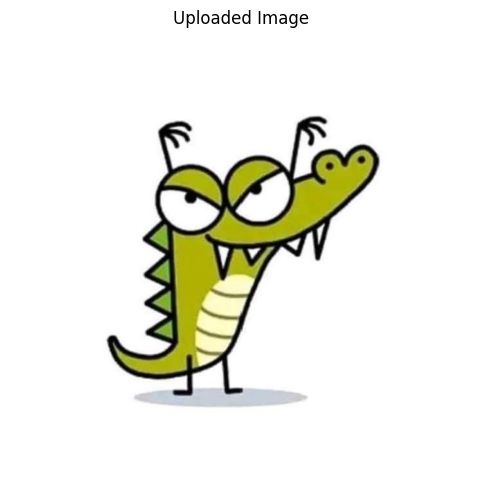

In [3]:
import matplotlib.pyplot as plt


image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

**2. Create a program that reads a colour image, converts it to grayscale, and saves both versions side by side for visual comparison.**

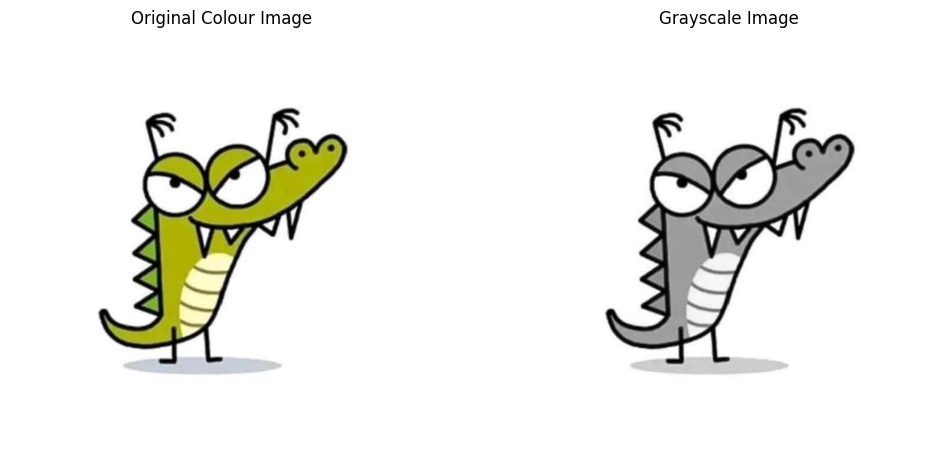

Original and grayscale images saved successfully!


In [4]:

import cv2
import matplotlib.pyplot as plt




file_name = list(uploaded.keys())[0]

image = cv2.imread(file_name)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Colour Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.show()


cv2.imwrite("original_colour_image.jpg", image)
cv2.imwrite("grayscale_image.jpg", gray_image)

print("Original and grayscale images saved successfully!")

**3. Develop an image format converter that takes one input image and exports it simultaneously as JPG, PNG, and BMP, then compares the resulting file sizes.**

Image loaded successfully!
Image converted successfully into JPG, PNG, and BMP!

----- FILE SIZE COMPARISON -----
JPG File Size: 33.11 KB
PNG File Size: 181.35 KB
BMP File Size: 1516.69 KB


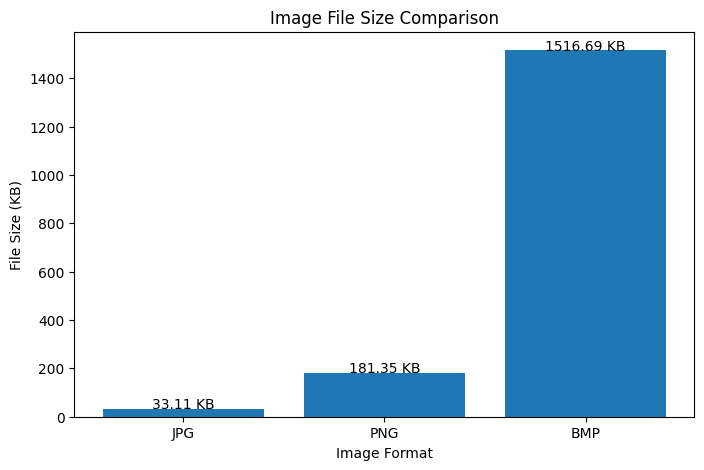

In [5]:
import cv2
import os
import matplotlib.pyplot as plt



file_name = list(uploaded.keys())[0]

image = cv2.imread(file_name)

if image is None:
    print("Error: Image could not be loaded.")
else:
    print("Image loaded successfully!")


    cv2.imwrite("converted_image.jpg", image)
    cv2.imwrite("converted_image.png", image)
    cv2.imwrite("converted_image.bmp", image)

    print("Image converted successfully into JPG, PNG, and BMP!")


    jpg_size = os.path.getsize("converted_image.jpg") / 1024
    png_size = os.path.getsize("converted_image.png") / 1024
    bmp_size = os.path.getsize("converted_image.bmp") / 1024


    print("\n----- FILE SIZE COMPARISON -----")
    print(f"JPG File Size: {jpg_size:.2f} KB")
    print(f"PNG File Size: {png_size:.2f} KB")
    print(f"BMP File Size: {bmp_size:.2f} KB")


    formats = ["JPG", "PNG", "BMP"]
    sizes = [jpg_size, png_size, bmp_size]


    plt.figure(figsize=(8, 5))
    plt.bar(formats, sizes)

    plt.title("Image File Size Comparison")
    plt.xlabel("Image Format")
    plt.ylabel("File Size (KB)")

    for i, size in enumerate(sizes):
        plt.text(i, size, f"{size:.2f} KB", ha="center")

    plt.show()

**4. Build a “photo negative” generator that computes and displays the complement of an uploaded image.**

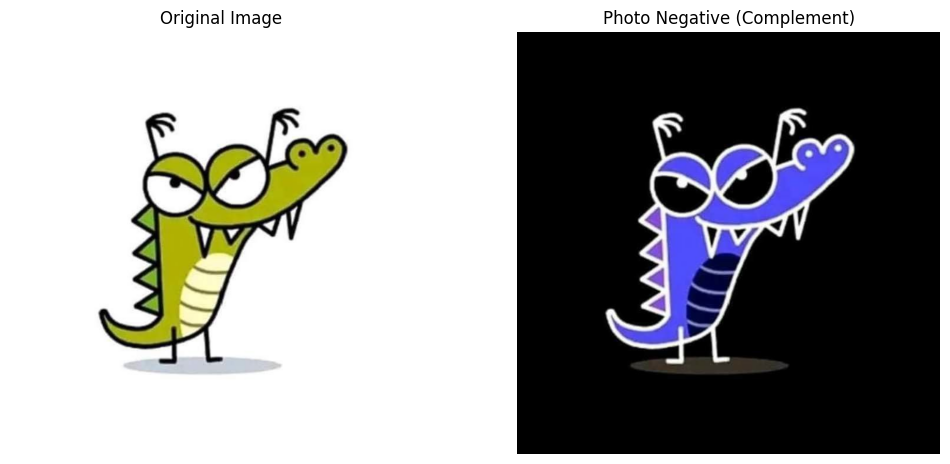

Photo negative created and saved successfully!


In [6]:

import cv2
import matplotlib.pyplot as plt


file_name = list(uploaded.keys())[0]

image = cv2.imread(file_name)

if image is None:
    print("Error: Image could not be loaded.")

else:

    negative_image = 255 - image


    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    negative_rgb = cv2.cvtColor(negative_image, cv2.COLOR_BGR2RGB)


    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis("off")


    plt.subplot(1, 2, 2)
    plt.imshow(negative_rgb)
    plt.title("Photo Negative (Complement)")
    plt.axis("off")

    plt.show()


    cv2.imwrite("photo_negative.jpg", negative_image)

    print("Photo negative created and saved successfully!")

**5. Create a batch image resizer that reads multiple images from a folder and saves resized copies while preserving the aspect ratio.**

In [7]:

import cv2
import os


output_folder = "resized_images"
os.makedirs(output_folder, exist_ok=True)

max_width = 500

print("Processing images...\n")

for file_name in uploaded.keys():

    image = cv2.imread(file_name)

    if image is None:
        print(f"Could not read: {file_name}")
        continue


    original_height, original_width = image.shape[:2]


    aspect_ratio = original_height / original_width


    new_width = max_width
    new_height = int(new_width * aspect_ratio)


    resized_image = cv2.resize(
        image,
        (new_width, new_height),
        interpolation=cv2.INTER_AREA
    )


    output_path = os.path.join(
        output_folder,
        f"resized_{file_name}"
    )


    cv2.imwrite(output_path, resized_image)


    print(f"Image: {file_name}")
    print(f"Original Size: {original_width} x {original_height}")
    print(f"Resized Size: {new_width} x {new_height}")
    print("-" * 40)

print("All images resized successfully!")

Processing images...

Image: 😐💗.jpg
Original Size: 720 x 719
Resized Size: 500 x 499
----------------------------------------
All images resized successfully!


**6. Develop a program that crops a user-specified Region of Interest (ROI) from an image and saves it as a separate file.**

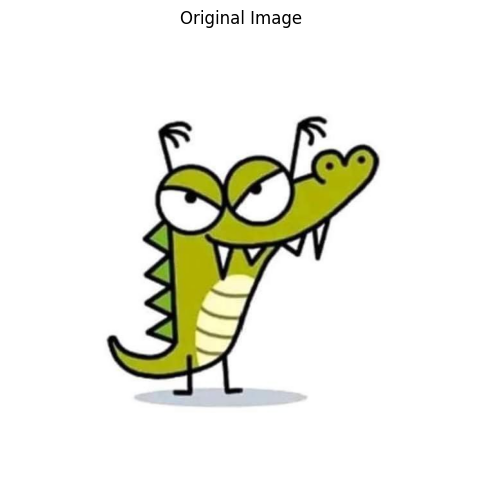

KeyboardInterrupt: Interrupted by user

In [8]:

import cv2
import matplotlib.pyplot as plt


file_name = list(uploaded.keys())[0]


image = cv2.imread(file_name)

if image is None:
    print("Error: Image could not be loaded.")

else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


    plt.figure(figsize=(8, 6))
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis("off")
    plt.show()


    x = int(input("Enter starting X coordinate: "))
    y = int(input("Enter starting Y coordinate: "))
    width = int(input("Enter ROI width: "))
    height = int(input("Enter ROI height: "))


    roi = image[y:y + height, x:x + width]


    if roi.size == 0:
        print("Invalid ROI coordinates!")

    else:

        roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)


        plt.figure(figsize=(12, 6))


        plt.subplot(1, 2, 1)
        plt.imshow(image_rgb)
        plt.title("Original Image")
        plt.axis("off")


        plt.subplot(1, 2, 2)
        plt.imshow(roi_rgb)
        plt.title("Cropped Region of Interest (ROI)")
        plt.axis("off")

        plt.show()

        cv2.imwrite("cropped_roi.jpg", roi)

        print("ROI cropped and saved successfully as cropped_roi.jpg")

**7. Build a tool that splits an image into its individual Red, Green, and Blue (RGB) channels, then reconstructs the image and verifies pixel-level accuracy.**

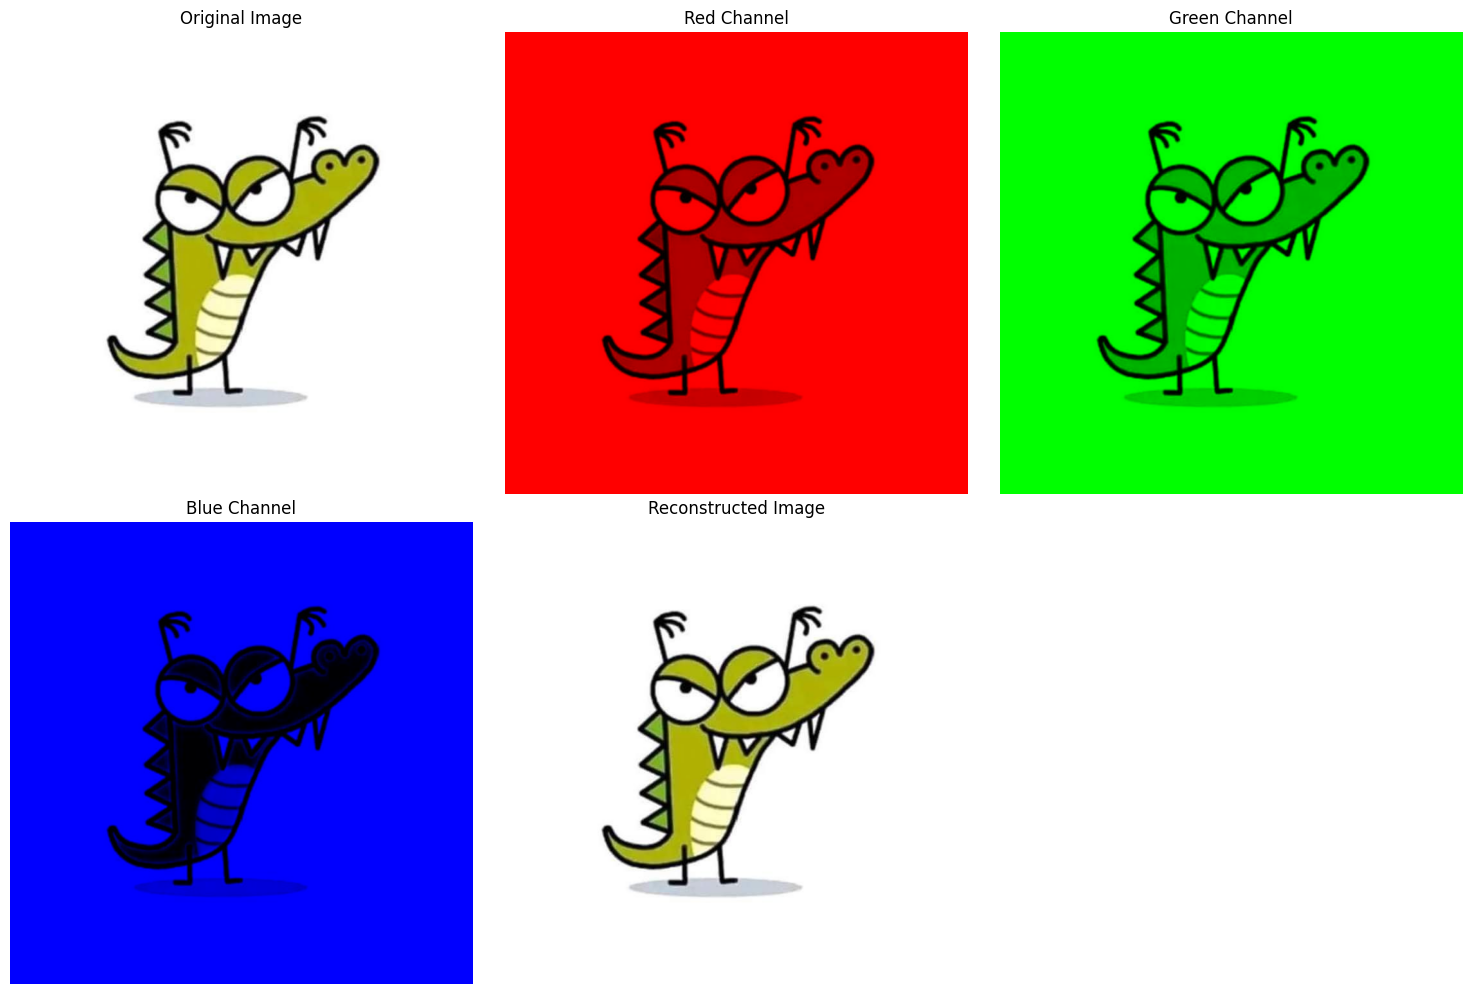

Pixel-Level Accuracy: 100%
Verification Successful!
The reconstructed image is exactly identical to the original image.
Reconstructed image saved successfully!


In [9]:

import cv2
import matplotlib.pyplot as plt
import numpy as np




file_name = list(uploaded.keys())[0]

image = cv2.imread(file_name)

if image is None:
    print("Error: Image could not be loaded.")

else:

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    R, G, B = cv2.split(image_rgb)


    red_channel = np.zeros_like(image_rgb)
    green_channel = np.zeros_like(image_rgb)
    blue_channel = np.zeros_like(image_rgb)


    red_channel[:, :, 0] = R
    green_channel[:, :, 1] = G
    blue_channel[:, :, 2] = B

    reconstructed_image = cv2.merge([R, G, B])


    plt.figure(figsize=(15, 10))
    plt.subplot(2, 3, 1)
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis("off")


    plt.subplot(2, 3, 2)
    plt.imshow(red_channel)
    plt.title("Red Channel")
    plt.axis("off")


    plt.subplot(2, 3, 3)
    plt.imshow(green_channel)
    plt.title("Green Channel")
    plt.axis("off")


    plt.subplot(2, 3, 4)
    plt.imshow(blue_channel)
    plt.title("Blue Channel")
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.imshow(reconstructed_image)
    plt.title("Reconstructed Image")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


    pixel_difference = np.abs(
        image_rgb.astype(int) - reconstructed_image.astype(int)
    )

    max_difference = np.max(pixel_difference)

    if np.array_equal(image_rgb, reconstructed_image):
        print("Pixel-Level Accuracy: 100%")
        print("Verification Successful!")
        print("The reconstructed image is exactly identical to the original image.")
    else:
        print("Verification Failed!")
        print("Maximum Pixel Difference:", max_difference)


    reconstructed_bgr = cv2.cvtColor(
        reconstructed_image,
        cv2.COLOR_RGB2BGR
    )

    cv2.imwrite("reconstructed_image.jpg", reconstructed_bgr)

    print("Reconstructed image saved successfully!")

**8. Create a watermarking utility that overlays a logo or text on an image and saves the watermarked output.**

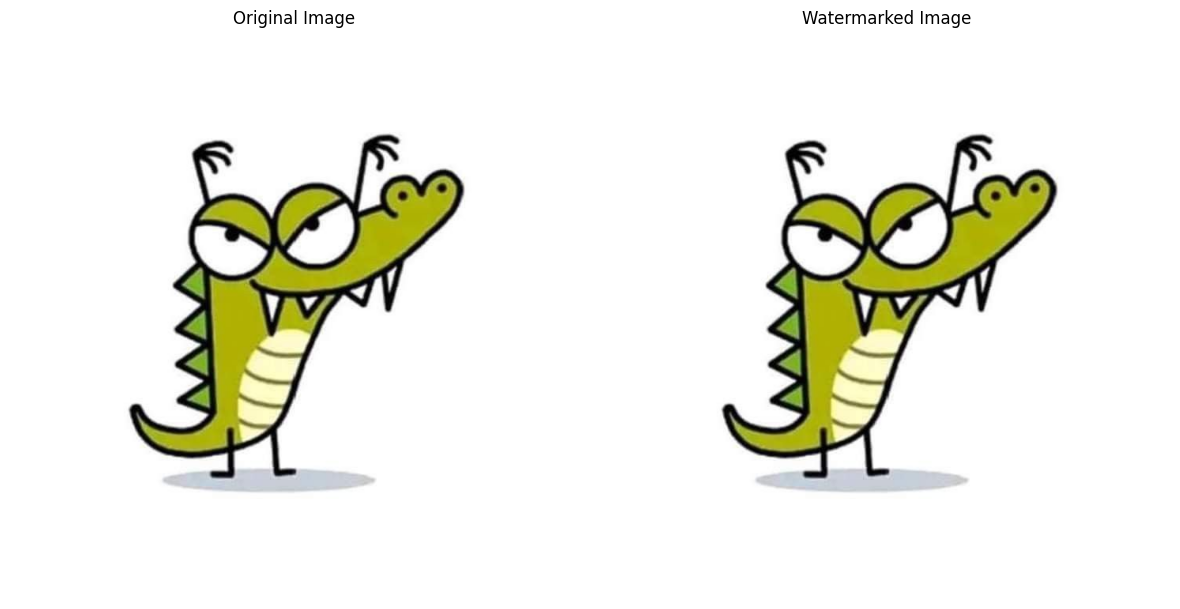

Watermarked image saved successfully!


In [10]:

import cv2
import matplotlib.pyplot as plt



file_name = list(uploaded.keys())[0]

image = cv2.imread(file_name)

if image is None:
    print("Error: Image could not be loaded.")

else:

    watermarked_image = image.copy()


    watermark_text = "Shivani Yadav"


    height, width = image.shape[:2]


    position = (50, height - 50)


    cv2.putText(
        watermarked_image,
        watermark_text,
        position,
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255, 255, 255),
        2,
        cv2.LINE_AA
    )


    original_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    watermarked_rgb = cv2.cvtColor(
        watermarked_image,
        cv2.COLOR_BGR2RGB
    )


    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(original_rgb)
    plt.title("Original Image")
    plt.axis("off")


    plt.subplot(1, 2, 2)
    plt.imshow(watermarked_rgb)
    plt.title("Watermarked Image")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


    cv2.imwrite(
        "watermarked_output.jpg",
        watermarked_image
    )

    print("Watermarked image saved successfully!")